In [1]:
from matplotlib import pyplot as plt
import pandas as pd

FIG_SIZE_X = 10
FIG_SIZE_Y = 5
DPI = 60
FONT_SIZE = 18

%matplotlib inline

In [2]:
# read csv file
df = pd.read_csv('gval.csv')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 61)
df

,Time_ps,H^0,H_2^0,H2O2^0,H3O^1,OH^0,OH^-1,e_aq^-1
0,1.00000,0.672835,0.188714,0.042165,4.13916,5.09864,0.006454,4.14056
1,1.25893,0.672835,0.188714,0.042165,4.13916,5.09864,0.006454,4.14056
2,1.58489,0.672846,0.188718,0.049482,4.13916,5.09864,0.007639,4.14056
3,1.99526,0.672846,0.188718,0.049482,4.13916,5.09864,0.007639,4.14056
4,2.51189,0.670585,0.188957,0.062438,4.13566,5.05508,0.008247,4.13589
5,3.16228,0.669500,0.189076,0.066033,4.13360,5.04114,0.008114,4.13333
6,3.98107,0.669505,0.189085,0.068608,4.13359,5.04100,0.008803,4.13331
7,5.01187,0.667643,0.189332,0.079253,4.12989,5.00877,0.009220,4.12853
8,6.30957,0.666583,0.189454,0.084611,4.12834,4.99516,0.009777,4.12644
9,7.94328,0.665767,0.189545,0.091215,4.12684,4.98068,0.010648,4.12451


In [3]:
label = {'H^0'   : 'H',   'H_2^0'  : 'H2',   'H2O2^0' : 'H2O2', 'H3O^1': 'H3Op', 
         'HO_2^0': 'HO2', 'HO_2^-1': 'HO2m', 'O^0'    : 'O',    'O_2^0': 'O2', 
         'O_2^-1': 'O2m', 'O_3^0'  : 'O3',   'O_3^-1' : 'O3m',   'OH^0': 'OH',
         'OH^-1' : 'OHm', 'O^-1'   : 'Om',   'e_aq^-1': 'e_aq'}

In [4]:
def plot(x, y, title):
    plt.figure(figsize = (FIG_SIZE_X, FIG_SIZE_Y), dpi = DPI)
    plt.plot(x, y, label = "Geant4-DNA", linewidth = 3.0)
    plt.grid(True)
    plt.title(title, fontsize = FONT_SIZE)
    plt.xlabel("Time (ps)", fontsize = FONT_SIZE)
    plt.ylabel("G-value", fontsize = FONT_SIZE)
    plt.xscale("log")
    plt.legend(fontsize = FONT_SIZE)
    plt.tick_params(labelsize = FONT_SIZE)
    plt.show()

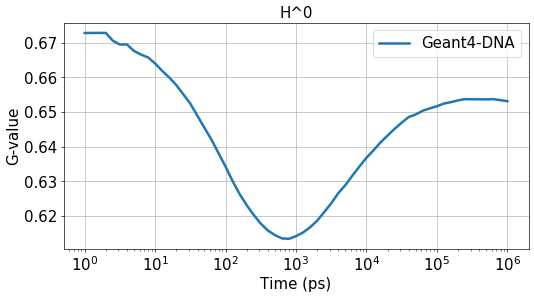

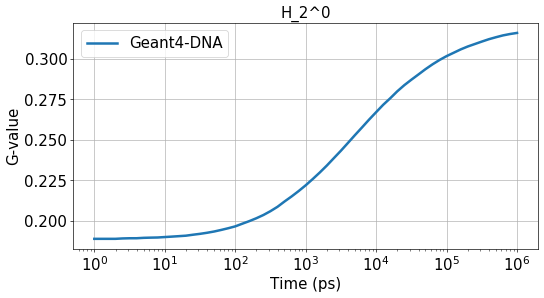

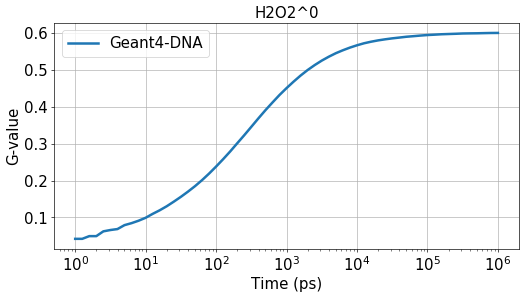

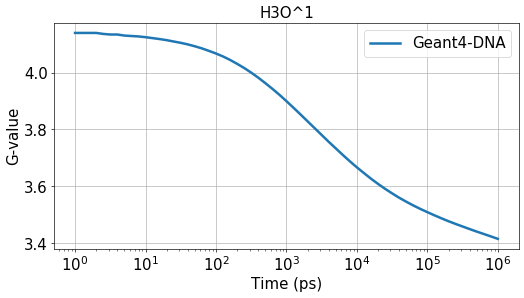

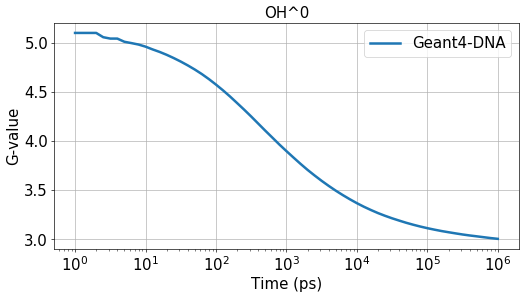

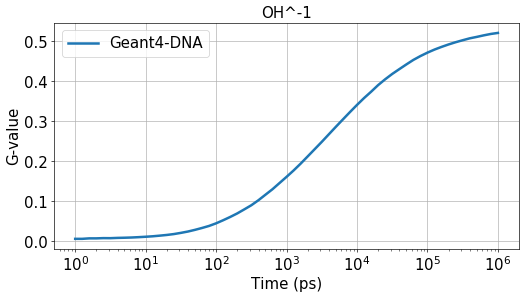

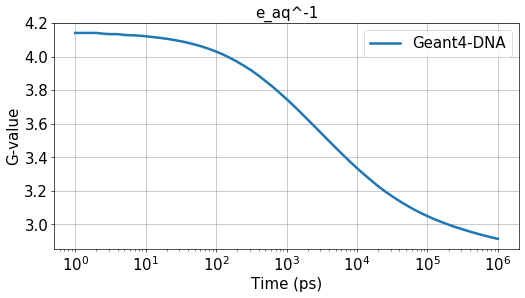

In [5]:
# make G-value plots
output = {"time": df['Time_ps'].values}
for x in df.columns:
    if x == 'Time_ps' or x == "None^0":
      continue
    plot(df['Time_ps'], df[x], x)
    output[label[x]] = df[x].values

# make data frame with Pandas and save as pickle file
pd.DataFrame.from_dict(output).to_pickle("gval.pkl")